<a href="https://colab.research.google.com/github/ed5555/22969-machine-learning-based-natural-language-applications/blob/main/final_project_git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

**The haiku generator: Generate a haiku poem by theme requests.**

The basic structure of haiku poems consists of 3 lines of text with a defined number of syllables at each one. Haiku poems usually revolve around imagery of nature, daily life and focus on fleeting moments.

Additionally, they contain two special types of words: '*kigo*' (=seasonal reference) and a '*kireji*' (=a 'cutting word' that interapts the contextual flow). Those create the vivid imagery of the poem and evoke the readers imagination.




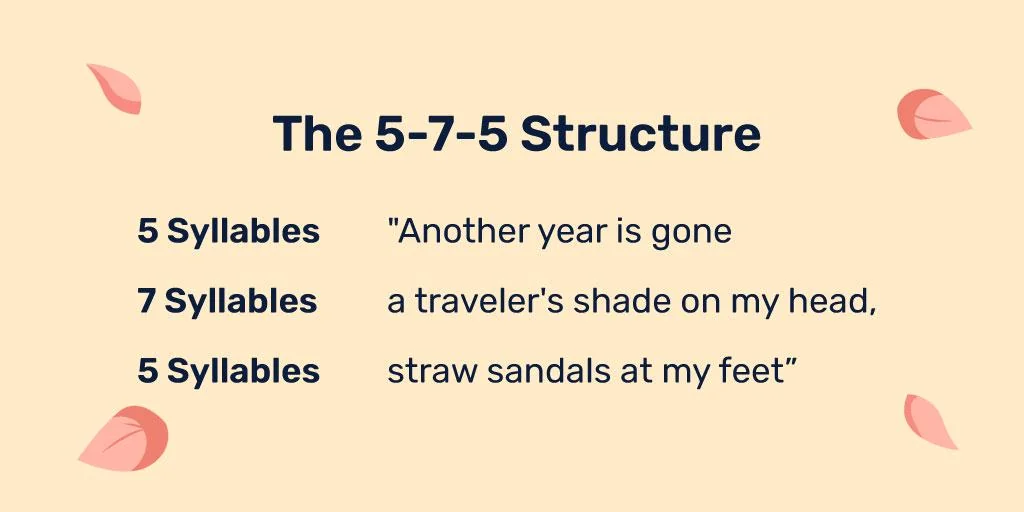

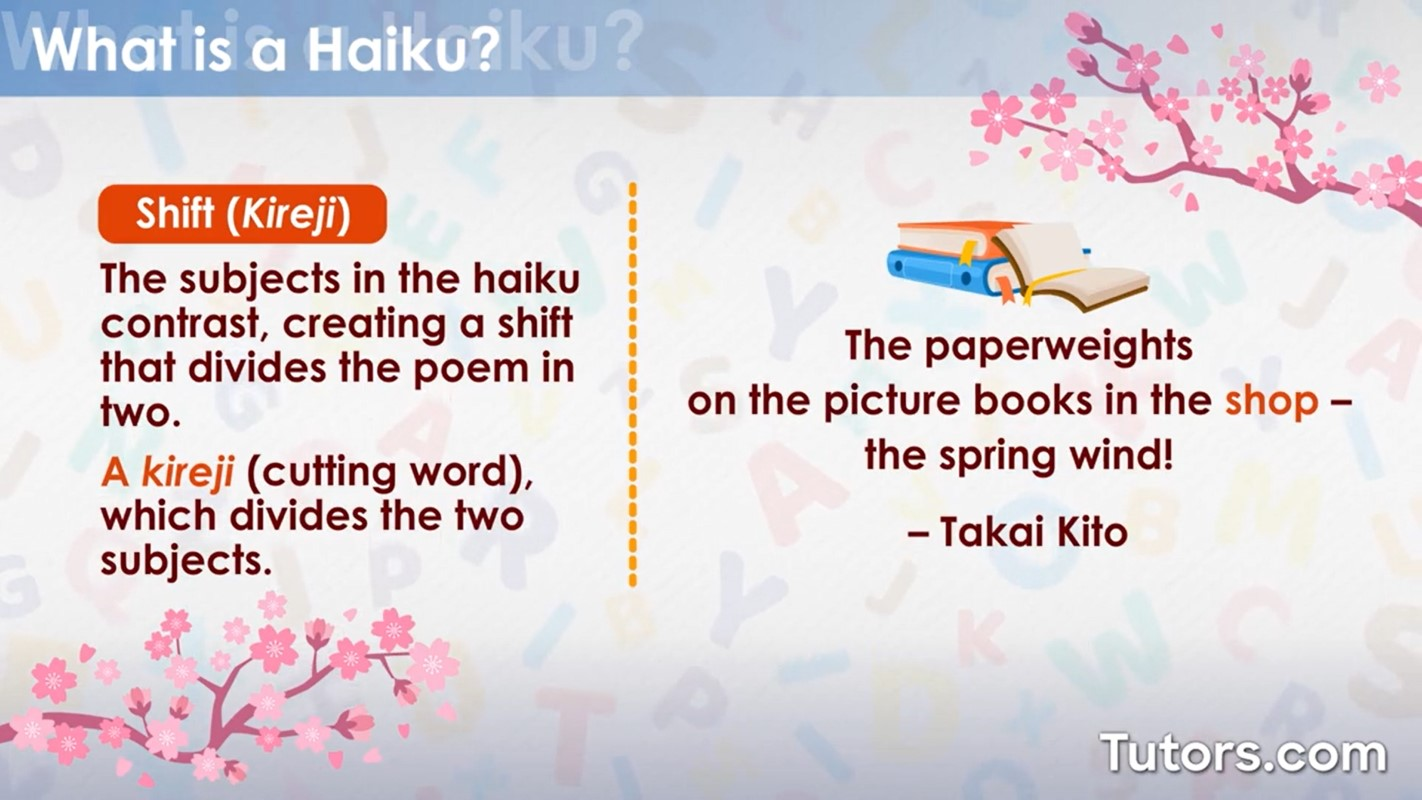

# 0. Importing the libraries and the code of the GPT-2 model

In [ ]:
import pandas as pd
import os
from tqdm.notebook import tqdm
import requests
import re
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import random
import torch.nn as nn
import tensorflow as tf
import json

The GPT-2 model and methods

Setting the device

In [ ]:
# Define the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # As in `CausalAttention`, for inputs where `num_tokens` exceeds `context_length`,
        # this will result in errors in the mask creation further below.
        # In practice, this is not a problem since the LLM (chapters 4-7) ensures that inputs
        # do not exceed `context_length` before reaching this forward method.

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x




class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits



def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())




def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in tqdm(enumerate(data_loader),desc='loss'):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches



def train_model_simple(model, train_loader, optimizer, num_epochs,
                       eval_freq, eval_iter, tokenizer,device=None):
    # Initialize lists to track losses and tokens seen
    train_losses , track_tokens_seen = [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in tqdm(range(num_epochs),desc='epochs'):
        model.train()  # Set model to training mode

        for i,(input_batch, target_batch) in enumerate(tqdm(train_loader,desc='train')):
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)

            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                model.train()
                train_losses.append(train_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}")

    return train_losses, track_tokens_seen



def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

# 1. Extracting and processing the data

In [ ]:
# theme keywords for categorizing the haikus


theme_keywords={
'earth': ['mountain','world','dust','bay','mud','desert','sand', 'forest', 'valley', 'canyon', 'earth','cliff','rock','stone', 'hill', 'shore', 'coast', 'beach', 'marsh', 'swamp', 'bog','field'],

'plant': ['thorn','tree','oak','grass','plant','cedar', 'growth','forest', 'leaf', 'foliage','soil','garden', 'field', 'wood','flower', 'blossom', 'bloom', 'petal', 'bud', 'rose','violet', 'iris', 'orchid','daisy', 'tulip', 'lily', 'peony','dandelion', 'sunflower','cherry', 'sakura', 'plum','camellia','stem', 'root', 'seed', 'sprout', 'bark','branch', 'trunk', 'pine', 'bamboo','grass', 'weed', 'fern','vine', 'ivy'],

'water': ['water','beach','lagoon','swamp','tear','dew','rain','snow','sink','drown', 'liquid', 'flow', 'current','stream', 'tide', 'wave','wet', 'moist','channel', 'damp','lake','river','pond','sea','ocean','waterfall','splash', 'drip','ice','icicle'],

'cold':['cold','icy','frozen','shiver','numb','tremble','chill','snow','ice','blizzard','storm','icicle','hail','frost','freeze','snowflake'],

'warm':['warm','firework','desert','smoke','tea','hot','sunny','sun','heat','fire','flame','ember','boil','candle','torch','melt','burn'],

'seasonal': ['blossom', 'cherry', 'sakura','snowflake', 'frost','thunder','harvest', 'foliage','cicada', 'firefly', 'cricket','winter','spring','autumn','summer','fall','cycle', 'midwinter', 'midsummer'],

'time': ['morning','minute','hour','past','now','future','dawn', 'sunrise', 'daybreak','noon', 'midday','evening', 'dusk', 'twilight', 'sunset','night', 'midnight', 'nightfall','moment', 'instant', 'fleeting','fast','slow','time','moment','instant'],

'celestial': ['space','planet','god','world','moon','aurora', 'lunar', 'crescent','sun', 'sunbeam','star', 'constellation','sky','cloud', 'overcast'],

'weather': ['rain','air', 'raindrop', 'shower', 'downpour', 'drizzle', 'mist','snow', 'snowfall', 'blizzard', 'sleet', 'hail','wind', 'breeze', 'gust', 'gale','storm', 'thunder', 'lightning', 'hurricane','fog', 'haze'],

'luminescence': ['light','darkness','dim','shine','firework', 'glow','shadow', 'shade', 'silhouette','dark', 'darkness', 'gloom','candle','evil', 'lantern', 'torch', 'lamp','reflection', 'mirror','moonlight', 'sunlight','illusion'],

'color': ['color','orange','pink', 'hue', 'shade', 'tone','white', 'black', 'gray','grey', 'silver', 'gold','red', 'crimson', 'scarlet','blue', 'azure','green', 'jade', 'olive','yellow', 'golden', 'amber','purple', 'violet', 'lavender'],

'animals': ['snake','turtle','lizard','firefly','dog','spider','frog', 'toad', 'tadpole','bird', 'sparrow', 'swallow', 'crow', 'raven', 'heron', 'crane', 'egret','insect','cricket', 'butterfly','cicada','bug', 'moth', 'dragonfly', 'bee', 'wasp','fish', 'carp', 'koi', 'salmon','deer', 'doe','fox', 'wolf', 'rabbit', 'squirrel','cat'],

'emotion': ['connection','cry','tear','lonely', 'loneliness', 'solitude', 'alone','quiet','fantasy', 'silence', 'dream','dreaming', 'calm', 'peace','word','tranquil','sad', 'sorrow', 'grief', 'melancholy', 'woe','joy', 'happy', 'delight', 'bliss', 'content', 'pleasure','love', 'affection', 'longing', 'yearning', 'desire','fear', 'dread', 'terror'],

'life': ['nest','dead','drown','childhood','birth','age','child','nun', 'youth','energy','ancestor','infant','senior','growth','pulse','breath', 'old', 'elder', 'aged', 'ancient','mother', 'father','son','daughter', 'family','friend','stranger','farmer','beginning','end','spirit','soul','memory','death','hunter'],

'activity': ['walk','dance', 'walking', 'stroll', 'wander','work', 'labor', 'task','rest', 'sleep', 'nap','wait', 'waiting', 'expectation','return','dreaming'],

'architecture': ['house','room', 'roof','castle', 'cottage', 'cabin', 'shack','temple', 'shrine','bridge', 'arch', 'gate', 'fence', 'wall','path', 'road', 'trail','window', 'door', 'entrance', 'exit','garden'],

'objects': ['bell','bowl','glass','cup','fan', 'chime','drum','flute','kimono','umbrella', 'lantern', 'lamp', 'candle','boat', 'ship', 'anchor','stone', 'rock', 'pebble', 'gravel','paper', 'scroll', 'book', 'letter', 'message','ink','feather'],

'senses': ['eye','beauty','ugly','pretty','sound','music', 'silence','bell' ,'chime','splash','voice', 'echo', 'whisper', 'chant','song','flute','drum', 'rhythm', 'noise', 'quiet', 'dark', 'color', 'bright', 'dim','touch','hand','finger','skin', 'soft', 'hard', 'smooth', 'rough', 'wet', 'dry','cold', 'warm', 'hot', 'cool','scent','nose', 'smell', 'fragrance', 'odor', 'aroma','perfume','taste','sweet','bitter','mouth','tongue'],

'description': ['word','new','frozen','thin','fresh','perfect','smooth', 'rough', 'deep','shallow', 'fine', 'delicate','soft', 'hard', 'firm', 'solid','wet', 'dry', 'damp', 'moist', 'humid', 'heavy', 'weight','small','tiny','large','big','low','tall','high','short','wide','narrow','beautiful','delicate','subtle'],

'existence': ['being','god','dead','war','fight','sin','drown','timeless','cry','tear', 'exist', 'life', 'living', 'alive','nothing', 'void', 'vacuum', 'absence','presence', 'essence', 'core', 'heart', 'center','spirit', 'soul', 'ghost','death','infinity'],

'japanese': ['flute','ghost','firework','sakura', 'cherry','blossom', 'pine','koi', 'carp', 'crane', 'turtle', 'monk', 'priest', 'shrine','sake', 'tea','kimono', 'yukata', 'obi', 'sash', 'geta', 'sandal','zen', 'meditation']}

In [ ]:
# creating a tiktoken object as well as adding endoftext token

tokenizer=tiktoken.get_encoding('gpt2')
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

Using Regex to pre-process the poems

In [ ]:
def clean_text(words):

  res=''
  vowels='aeiou'

  for text in words.split():

    # remove any special charactes as well normalize to lower case for easier cleaning
    cleaned = re.sub(r'[^\w\s]', '', text)
    cleaned = re.sub(r'[?!]', '', cleaned)
    cleaned = re.sub(r'\n', ' ', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    cleaned = cleaned.lower().strip()

    # remove plural suffixes

    # 'ies' -> 'y'
    cleaned = re.sub(r'\b(\w+)ies\b', r'\1y', cleaned)


    # 'ves'-->'f'
    if cleaned.endswith('ves'):
      cleaned = re.sub(r'\b(\w+)ves\b', r'\1f', cleaned)

      if len(cleaned)>2:
        if cleaned[-2] in vowels and cleaned[-3] not in vowels:
          cleaned+='e'

    # 'es'-->'e'
    if cleaned.endswith('es'):
      cleaned = re.sub(r'\b(\w+[sxzchsh])es\b', r'\1', cleaned)

      if cleaned[-2] in vowels:
        cleaned+='e'

    # 's'-->no 's'
    if len(cleaned)>3: # avoid removing 's' from short words like 'is', 'has'...
      cleaned = re.sub(r'\b(\w+[abcdefghijklmnopqrstuvwxyz])s\b', r'\1', cleaned)

    res+=cleaned+' ' # reconstruct the haiku word by word

  return res.strip()

Tagging the poems by their content

In [ ]:
# add themes to every haiku based on its content. Entries without a theme are excluded

def add_themes(haikus,theme_keywords):

  haiku_themes={}

  for haiku in haikus:

    themes=[]

    # get all clean and unique words for theme assignment
    haiku_set=set((clean_text(haiku)).split())

    for theme,keywords in theme_keywords.items():

      keywords_set=set(keywords)

      # if there's at least one similar keyword assign the theme
      if len(keywords_set & haiku_set)>0:
        themes.append(theme)

    # if any themes found, add to the dictionary
    if themes:
      haiku_themes[haiku]=themes

  return haiku_themes

Extracting the haiku poems

In [ ]:
url_1='https://raw.githubusercontent.com/herval/creative_machines/master/haikuzao/src/main/resources/haiku.txt'
url_2='https://raw.githubusercontent.com/docmarionum1/haikurnn/refs/heads/master/input/poems/raw/sballas8.csv'
url_3='https://raw.githubusercontent.com/docmarionum1/haikurnn/refs/heads/master/input/poems/raw/gutenberg.csv'
df = pd.read_parquet("hf://datasets/statworx/haiku/train.parquet")

In [ ]:
response_1=requests.get(url_1)
haikus_1=list(response_1.text.strip().split('\n\n'))

response_2=pd.read_csv(url_2,header=None)[0].tolist()
haikus_2=[h.rstrip('\n') for h in response_2]

response_3=pd.read_csv(url_3)['haiku']
haikus_3=[h.rstrip('\n') for h in response_3]

response_4=df['text']
haikus_4 = ['\n'.join(line.split('.')[0].strip() for line in h.split('/')) for h in response_4]


haikus=haikus_1+haikus_2+haikus_3+haikus_4

# remove initial and trailing special characters from the haiku poems
haikus = [haiku.strip().strip('"').strip('-').strip(',').strip('.').strip('\'').strip('\n') for haiku in haikus]


# removing poems that contain too little/many words and that contain non-relevant characters
haikus = [
    haiku for haiku in haikus
    if len(haiku.split('\n'))==3
    and 3 < len(haiku.split())<21
    and not re.search(r'[_\[\](){}|@#$%^&*+=<>]', haiku)]


# assigning themes to all entries
data=add_themes(haikus,theme_keywords)

In [ ]:
# transforming the data into a list of dictionaries for easier processing

data = [{'haiku': haiku, 'themes': themes} for haiku, themes in data.items()]

In [ ]:
# an example of the dataset

print(data[0])

# 2. Plotting

In [ ]:
# Number of entries before and after filtering for themes

print(f'Number of haikus in the original dataset: {len(haikus)}')
print(f'Number of haikus after excluding themeless poems: {len(data)}')

In [ ]:
# filtering and extracting poems by a certain theme

def filter_by_theme(data,theme):

  filtered_haiku=[val for val in data if theme in val['themes']]

  return filtered_haiku

Visualizing the data

In [ ]:
# basic statistics of the poems

haiku_lengths_chars=[len(item['haiku'])for item in data]
haiku_lengths_words=[len(item['haiku'].split())for item in data]


print(f'max length chars: {np.max(haiku_lengths_chars)}, max length words: {np.max(haiku_lengths_words)}')
print(f'min length chars: {np.min(haiku_lengths_chars)}, min length words: {np.min(haiku_lengths_words)}')
print(f'mean length chars: {np.mean(haiku_lengths_chars):.2f}, mean length words: {np.mean(haiku_lengths_words):.2f}')
print('\n')



fig,ax=plt.subplots(1,2,figsize=(12,6))

ax[0].hist(haiku_lengths_chars, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Number of characters', fontsize=12)
ax[0].set_title('Number of characters distribution', fontsize=14)

ax[1].hist(haiku_lengths_words, bins=30, color='olive', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('Number of words', fontsize=12)
ax[1].set_title('Number of words distribution', fontsize=14)

fig.supylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
num_themes_freq={}


for val in data:
  num_themes=len(val['themes'])

  if num_themes not in num_themes_freq:
    num_themes_freq[num_themes]=0
  num_themes_freq[num_themes]+=1


plt.bar(num_themes_freq.keys(), num_themes_freq.values(),color='goldenrod')
plt.title('Number of themes frequency')
plt.xlabel('Number of themes')
plt.ylabel('Count')
plt.xticks(list(num_themes_freq.keys()))
plt.show()

In [ ]:
# visualize theme frequency

themes_count = {}

for theme in theme_keywords.keys():
    filtered_haiku = filter_by_theme(data, theme)
    themes_count[theme] = len(filtered_haiku)

# Sort themes by count in descending order
sorted_items = sorted(themes_count.items(), key=lambda x: x[1], reverse=True)

# Unzip into separate lists
sorted_themes, sorted_counts = zip(*sorted_items)

# Create the bar chart
plt.bar(sorted_themes, sorted_counts,color='lightcoral')
plt.xticks(rotation=90)
plt.xlabel('Themes')
plt.ylabel('Count')
plt.title('Haiku frequency by theme')
plt.tight_layout()
plt.show()

In [ ]:
# visualize the top n most common words among all poems

words_count={}

for val in data:

  haiku=val['haiku'].split()

  for word in haiku:

    if word.lower() not in words_count:
      words_count[word.lower()]=0
    words_count[word.lower()]+=1

most_n_frequent=15

sorted_words = sorted(words_count.items(), key=lambda x: x[1], reverse=True)[:most_n_frequent]

most_common_words, counts = zip(*sorted_words)

plt.bar(most_common_words, counts,color='teal')
plt.xlabel('Words')
plt.ylabel('Count')
plt.title(f'Top {most_n_frequent} most common words in the dataset')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# count keyword frequency for every theme

keyword_count={}

for theme in theme_keywords:
  filtered_haiku=filter_by_theme(data,theme)

  if theme not in keyword_count:
    keyword_count[theme]={}

  for keyword in theme_keywords[theme]:

    for haiku in filtered_haiku:

      if keyword in haiku['haiku']:
        if keyword not in keyword_count[theme]:

          keyword_count[theme][keyword]=0
        keyword_count[theme][keyword]+=1

In [ ]:
# visualizing keyword frequency per theme

fig, axes = plt.subplots(7,3, figsize=(21, 26))

axes_flat = axes.flatten()

for i, (theme, key_counts) in enumerate(keyword_count.items()):

    sorted_key_counts = sorted(key_counts.items(), key=lambda x: x[1], reverse=True)

    # Keep only top x% of keywords
    num_to_keep = max(1, int(len(sorted_key_counts) * 0.5))
    top_key_counts = sorted_key_counts[:num_to_keep]

    if top_key_counts:
        words, counts = zip(*top_key_counts)

    else:
        words, counts = [], []

    ax = axes_flat[i]

    if words:
        bars = ax.bar(range(len(words)), counts, color='thistle')
        ax.set_title(f'{theme}')

        ax.set_xticks(range(len(words)))
        ax.set_xticklabels(words, rotation=90, fontsize=8)

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{theme}')


fig.supxlabel('Keywords')
fig.supylabel('Count')
plt.suptitle('Keyword Frequency by Theme', fontsize=16, y=1.02)
plt.tight_layout(pad=2.0)
plt.show()

# 3. Dataloader

Assign model hyper-parameters and augmentation

In [ ]:
# extremely common keywords that will be occasionally replaced

replace_keywords_dict={'wind':['air','storm','mist','breeze'],'sun':['heat','flame','fire','candle'],'snow':['blizzard','icicle','frost','ice'],'night':['evening','dusk','midnight','sunset','twilight'],
                       'morning':['dusk','dawn','sunset','twilight'],'moon':['crescent','sun','star','cloud','lunar'],'rain':['river','wave','pond','shower','mist','waterfall','hurricane'],'light':['shade','reflection','glow','sunlight','darkness'],
                       'old':['ancient','family','soul','memory'],'end':['death','spirit','soul','absence'],'love':['lonely','happy','sad','joy','grief','bliss',
                       'yearning','longing'],'life':['living','being','death','void','spirit'],'white':['gray','silver','crimson'],'blue':['lavender','gold','purple'],
                       'new':['thin','fresh','perfect','soft','beautiful'],'dog':['spider','sparrow','frog','cat','squirrel'],'tree':['oak','bud','pine','weed']}

In [ ]:
drop_rate_model=0.18
change_rate_words=0.22
eval_freq_model=50
eval_iter_model=5
top_k_model=150
batch_size=64
weight_decay_model=0.01
lr_model=0.0001
epochs=1
max_context_length=256

Prompt creating methods: one for training (adding the haiku) and one for testing (without a haiku) with slight variation

In [ ]:
# prompt for validation: instructures without the haiku

def create_prompt_no_haiku(haiku):
    themes_str = ",".join(haiku['themes'])

    prompt_variations = [
        f"Write a haiku about:\n{themes_str}",
        f"Compose a haiku inspired by the themes:\n{themes_str}",
        f"Create a haiku poem with themes of:\n{themes_str}",
        f"Haiku with themes {themes_str}:",
        f"Three-line haiku about {themes_str}:",
    ]

    return random.choice(prompt_variations)

In [ ]:
# prompt for training: instructures with the haiku

def create_prompt_with_haiku(haiku,change=0.15):

    train_prompt=create_prompt_no_haiku(haiku)

    if torch.rand(1)<change:
      train_prompt+=f'\n\nThe resulting Haiku:\n{haiku['haiku']}'
    else:
      train_prompt+=f'\n\nHaiku:\n{haiku['haiku']}'
    return train_prompt

Collating methods from the original GPT-2 model

In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
customized_collate_fn = partial(
    custom_collate_fn,
    allowed_max_length=max_context_length,
    device=device
)

Dataset and Dataloader objects

In [ ]:
# creating the haiku dataset class

class haiku_dataset(Dataset):

  def __init__(self,data,tokenizer,rate,dropout_words):

    self.encoded_haiku=[]

    for haiku in data:

      haiku_poem=haiku['haiku']
      haiku_poem_split=haiku_poem.split()
      themes=haiku['themes']

      modified_haiku=haiku_poem

      temp={}

      # if the rate is >0, randomly replace common theme keywords
      if rate>0:

        for word,replacements in dropout_words.items():
          if word in haiku_poem_split and round(torch.rand(1).item())<rate:
            modified_haiku=haiku_poem.replace(word,random.choice(replacements))


      temp['haiku']=modified_haiku
      temp['themes']=themes

      # encode the prompted haiku using the tokenizer object
      encoded_haiku=tokenizer.encode(create_prompt_with_haiku(temp))
      self.encoded_haiku.append(encoded_haiku)


  def __len__(self):
    return len(self.encoded_haiku)

  def __getitem__(self,idx):
    return self.encoded_haiku[idx]

In [ ]:
train_data=data

In [ ]:
train_dataset = haiku_dataset(train_data, tokenizer,change_rate_words,replace_keywords_dict)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
)

# 4. Get GPT-2 pre-trained weights and finetune on haiku poems

In [ ]:
def download_and_load_gpt2(model_size, models_dir,context_length=1024):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings,context_length)

    return settings, params


def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        response = requests.get(download_url, stream=True, timeout=60)
        response.raise_for_status()

        file_size = int(response.headers.get("Content-Length", 0))

        # Check if file exists and has same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size and file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return True

        block_size = 1024  # 1 KB
        desc = os.path.basename(download_url)
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=desc) as progress_bar:
            with open(destination, "wb") as file:
                for chunk in response.iter_content(chunk_size=block_size):
                    if chunk:
                        file.write(chunk)
                        progress_bar.update(len(chunk))
        return True

    try:
        if _attempt_download(url):
            return
    except requests.exceptions.RequestException:
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except requests.exceptions.RequestException:
                pass

        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings, context_length=1024):
    """
    Load GPT-2 parameters from TensorFlow checkpoint.

    Args:
        ckpt_path: Path to TensorFlow checkpoint
        settings: Model hyperparameters from hparams.json
        context_length: Optional custom context length. If provided,
                       position embeddings will be truncated to this length.
    """
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # If this is position embeddings and context_length is specified
        if variable_name_parts == ["wpe"] and context_length is not None:
            original_length = variable_array.shape[0]
            if original_length > context_length:
                # Truncate to requested context length
                variable_array = variable_array[:context_length]
            elif original_length < context_length:
                # Pad with zeros if needed (unlikely for GPT-2)
                padding = np.zeros((context_length - original_length, variable_array.shape[1]))
                variable_array = np.vstack([variable_array, padding])

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [ ]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": max_context_length,  # Context length
    "drop_rate": drop_rate_model,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2",
    context_length=BASE_CONFIG["context_length"]
)



model = GPTModel(BASE_CONFIG)

load_weights_into_gpt(model, params)
model=model.to(device)
model.eval();

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr_model, weight_decay=weight_decay_model)



train_losses, tokens_seen = train_model_simple(
    model, train_loader, optimizer,
    num_epochs=epochs, eval_freq=eval_freq_model, eval_iter=eval_iter_model,
    tokenizer=tokenizer,device=device
)

# 5. Comparison methods

Various methods for analyzing the generated poem

In [ ]:
def plot_similarities(similarities, similarities_per, theme=None):
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    x_indices = range(len(similarities))

    ax[0].bar(x_indices, similarities, label='similarities', color='skyblue')
    ax[0].set_title(f'similarities count (mean: {np.average(similarities):.2f})')

    # For percentages, ensure we have the same length
    if len(similarities_per) != len(similarities):
        x_indices_per = range(len(similarities_per))
    else:
        x_indices_per = x_indices

    ax[1].bar(x_indices_per, similarities_per, label='similarities %', color='olive')
    ax[1].set_title(f'similarities % (mean: {np.average(similarities_per):.2f})')

    # Fix the string formatting issue in the suptitle
    title_text = f'Similarities{": " + theme if theme else ""}'
    fig.suptitle(title_text)
    fig.supxlabel('Haiku index')
    fig.supylabel('Value')
    fig.tight_layout()
    plt.show()

In [ ]:
# extract all themes associated with a haiku

def get_themes(haiku):


  haiku_temp =[haiku.strip()]

  themed_haiku=add_themes(haiku_temp,theme_keywords)

  if not themed_haiku:
    print('no themes found')
    return
  themes=list(themed_haiku.values())[0]
  return themes

In [ ]:
# compare a haiku to the dataset by the number of similar words (count and %)

def compare_haiku(haiku,data):

  haiku_words=set([word for word in haiku.split()])


  similarities_per=[]
  similarities=[]

  most_common_words_set=set(most_common_words)

  for val in data:

    val_words=set(val['haiku'].split())

    # compare only unique words and subtract the n most common words found earlier
    common_words=haiku_words & val_words - most_common_words_set
    common_words_per=100*len(common_words)/len(val_words)

    similarities.append(len(common_words))
    similarities_per.append(common_words_per)

  return similarities,similarities_per

In [ ]:
# compare similarity of a haiku to all haikus with the same theme

def compare_by_theme(data,haiku):
  themes=get_themes(haiku)

  if not themes:
    return
  for theme in themes:
    filtered_haiku=filter_by_theme(data,theme)
    sim,sim_per=compare_haiku(haiku,filtered_haiku)
    plot_similarities(sim,sim_per,theme)
    print('\n')

# 6. Testing

In [ ]:
# all possible themes

themes= ['earth','plant','water','cold','warm','seasonal','time','celestial','weather','luminescence','color','animals','emotion','life','activity','architecture','objects','senses','description','existence','japanese']

temps=np.arange(0.2,1.2,0.2)

Tests:

In [ ]:
def generate_haiku(entry,temperature=0.7):
  input_text = create_prompt_no_haiku(entry)


  token_ids = generate(
      model=model,
      idx=text_to_token_ids(input_text, tokenizer).to(device),
      max_new_tokens=60,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256,
      temperature=temperature,
      top_k=top_k_model
      )

  generated_text = token_ids_to_text(token_ids, tokenizer)
  print(generated_text)
  return generated_text

In [ ]:
def haiku_test(res,themes,compare=False):

  haiku=res.split('Haiku:')[1]

  lines_num=len(haiku.strip().strip('"').strip('-').strip(',').strip('.').strip('\'').strip('\n').split('\n'))

  if lines_num==3:
    print('✓: correct number of lines')
  else:
    print('✗: incorrect number of lines')


  res_themes=get_themes(haiku)

  if not res_themes:
    print('✗: no themes found')
  else:
    res_themes=set(res_themes)

    themes_set=set(themes)

    num_common_themes_per=100*len(res_themes & themes_set)/len(themes_set)

    if num_common_themes_per==100:
      print('✓✓✓: perfect themes coverage!')
    elif num_common_themes_per>75:
      print('✓✓: very good themes coverage')
    elif num_common_themes_per>50:
      print('✓: good themes coverage')
    else:
      print('✗: bad themes coverage...')

  if compare:
    print('='*100)
    compare_by_theme(data,res)

In [ ]:
entry={'haiku':'','themes':['senses','seasonal','time']}

In [ ]:
for temp in temps:
  print(f'*********************** temperature: {temp:.1f} *****************************')
  res=generate_haiku(entry,temperature=0.8)
  haiku_test(res,entry['themes'])
  print('\n')

In [ ]:
entry={'haiku':'','themes':['japanese','activity','objects']}

In [ ]:
for temp in temps:
  print(f'*********************** temperature: {temp:.1f} *****************************')
  res=generate_haiku(entry,temperature=temp)
  haiku_test(res,entry['themes'])
  print('\n')

In [ ]:
entry={'haiku':'','themes':['water']}

res=generate_haiku(entry)
haiku_test(res,entry['themes'],compare=True)
print('\n')

In [ ]:
entry={'haiku':'','themes':['vehicles']}

res=generate_haiku(entry)
haiku_test(res,entry['themes'],compare=True)
print('\n')